In [1]:
import numpy as np
import pickle
from utils import reorder_transition_matrix, get_max_pb_file
import matplotlib.pyplot as plt
import os
import multiprocessing as mp

# import IMP.npctransport

In [2]:
def sim_mm(tm, length=1000, init_dist=None):
    # init_state = np.random.choice([0,len(tm) - 1], p=[0.5, 0.5]) # Start in nucleus or cytoplasm
    if init_dist is None:
        init_state = np.random.choice(list(range(len(tm))), p=[1/len(tm) for _ in range(len(tm))]) # Start in any state
    else:
        init_state = np.random.choice(list(range(len(tm))), p=init_dist)
    cur_state = init_state
    sim = [cur_state]
    for i in range(length):
        cur_state = np.random.choice(range(len(tm)), p=tm[cur_state])
        sim.append(cur_state)
    return sim
        
        
def calc_transports(sim, bottom_states, top_states):
    transports = 0
    cur = None
    for i in range(len(sim)-1):
        if cur == None:
            if sim[i+1] in bottom_states:
                cur = 0
                continue
            elif sim[i+1] in top_states:
                cur = 1
                continue
        elif cur == 0 and sim[i+1] in top_states:
            transports += 1
            cur = 1
        elif cur == 1 and sim[i+1] in bottom_states:
            transports += 1
            cur = 0
    return transports

def permiability_from_path(matrix_path, n_sims=1000, sim_length=1000, bottom_states=None, top_states=None, init_dist=None):
    with open(matrix_path, "rb") as f:
        tm, states = pickle.load(f)
        
    # Load anchor coordinates
    with open(f"data/anchor_coordinates.pickle", "rb") as f:
        anchor_coordinates = pickle.load(f)
    
    # Sort anchor coordinates by Z and reorder transition matrix
    anchor_coordinates = dict(sorted(anchor_coordinates.items(), key=lambda x: x[1][2]))
    new_states = ["nuc"] + list(anchor_coordinates.keys()) + ["cyt"]
    tm = reorder_transition_matrix(tm, states, new_states)
    
    # Simulate
    transports = []
    for i in range(n_sims):
        sim = sim_mm(tm, length=sim_length, init_dist=init_dist)
        transports.append(calc_transports(sim, bottom_states, top_states))
    return np.sum(transports)

In [6]:
permiability_from_path(matrix_path=f"data/transition_matrices/interactions-150-180-symmetric-{100}ns.pickle",
                       n_sims=250, # 5 molecules = 1 uM, 250 molecules = 50 uM
                       sim_length=300) # 10000 steps = 1 ms, 1000 steps = 100 us

17

1 ms = 1000 us = 1000 * 1000 ns = 10,000 * 100 ns

13 molecules / 5e-5 s / 50 uM / NPC
=
1.16 molecules / 5e-5 s / uM / NPC
=
5,200 molecules / s / uM / NPC

In [14]:
for i in [0, 1, 2, 4, 8, 16, 32, 64]:
    perm = permiability_from_path(matrix_path=f"/cs/usr/roi.eliasian/LabFolder/Master/NPC-markov/data/transition_matrices/interactions-150-180-sym-diag+{i}.pickle",
                       n_sims=250, # 5 molecules = 1 uM, 250 molecules = 50 uM
                       sim_length=300) # 10000 steps = 1 ms, 1000 steps = 100 us
    print(f"Permeability for {i} diag: {perm}")

Permeability for 0 diag: 300
Permeability for 1 diag: 316
Permeability for 2 diag: 280
Permeability for 4 diag: 286
Permeability for 8 diag: 311
Permeability for 16 diag: 308
Permeability for 32 diag: 297
Permeability for 64 diag: 314


In [64]:
def md_premiabilty_pb(pb_path):
    output = IMP.npctransport.Output()
    with open(pb_path, "rb") as f:
        fstring = f.read()
        output.ParseFromString(fstring)
        del fstring
    transports = np.array(output.statistics.floaters[0].transport_time_points_ns) # kap35
    # print(transports)
    return transports[transports > 100000]

/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_50uM_1ns/divergences/1/222900.pb
/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_50uM_1ns/divergences/2/222900.pb
/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_50uM_1ns/divergences/3/197600.pb
/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_50uM_1ns/divergences/4/198200.pb
/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_50uM_1ns/divergences/5/198000.pb
/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_50uM_1ns/divergences/6/198300.pb
/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_50uM_1ns/divergences/7/202100.pb
/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_50uM_1ns/divergences/8/202300.pb
/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_50uM_1ns/diverge

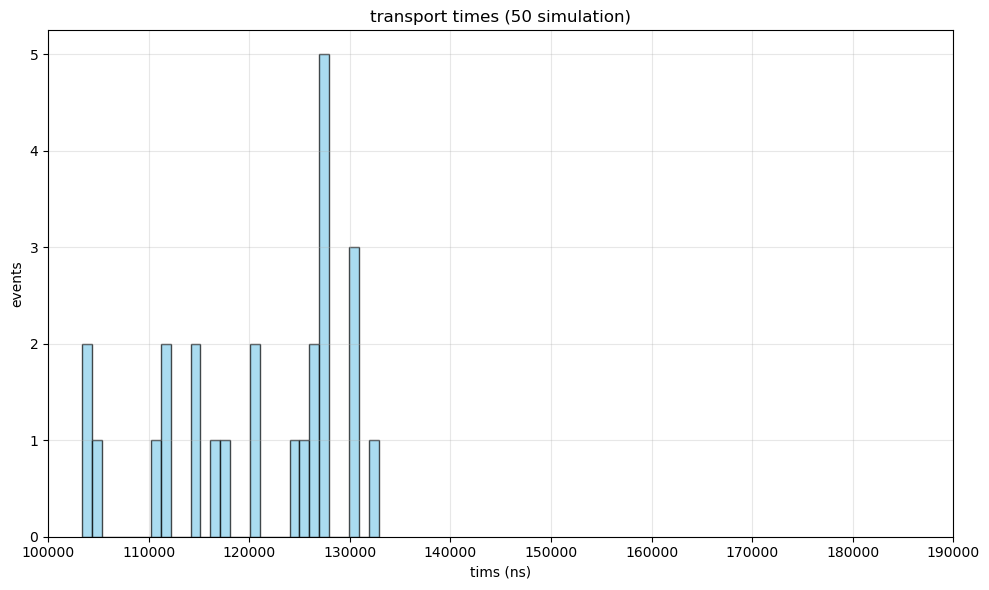

In [67]:
max_pb = get_max_pb_file("/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_50uM_1ns/divergences/10/")
transports = []
for i in range(1, 51):
    max_pb = get_max_pb_file(f"/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_50uM_1ns/divergences/{i}/")
    print(max_pb)
    transports += md_premiabilty_pb(max_pb).tolist()
    
import matplotlib.pyplot as plt
    
plt.figure(figsize=(10, 6))
plt.hist(transports, bins=30, alpha=0.7, color='skyblue', edgecolor='black')

# # Add labels and title
plt.xlabel('tims (ns)')
plt.ylabel('events')
plt.title('transport times (50 simulation)')

# Add grid and show plot
plt.xlim(100000, 190000)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
def plot_side_by_side_histograms(array1, array2, bins=10, labels=None, titles=None, figsize=(12, 5)):
    """
    Display histograms of two 1D numpy arrays side by side with frequencies shown as fractions.
    Uses the same y-axis range for both histograms for better comparison.
    
    Parameters:
    -----------
    array1 : numpy.ndarray
        First 1D array to plot
    array2 : numpy.ndarray
        Second 1D array to plot
    bins : int or sequence, optional
        Number of bins for the histograms (default: 10)
    labels : tuple of str, optional
        Labels for the arrays in the legend (default: None)
    titles : tuple of str, optional
        Titles for the subplots (default: None)
    figsize : tuple of float, optional
        Figure size in inches (width, height) (default: (12, 5))
    """
    # Input validation
    if not isinstance(array1, np.ndarray) or not isinstance(array2, np.ndarray):
        raise TypeError("Inputs must be numpy arrays")
    if array1.ndim != 1 or array2.ndim != 1:
        raise ValueError("Inputs must be 1D arrays")
        
    # Set default values
    if labels is None:
        labels = ('Array 1', 'Array 2')
    if titles is None:
        titles = ('Histogram of Array 1', 'Histogram of Array 2')
    
    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, sharey=True)  # Added sharey=True
    
    # Compute histograms to get max density value
    hist1, bins1 = np.histogram(array1, bins=bins, density=True)
    hist2, bins2 = np.histogram(array2, bins=bins, density=True)
    
    # Determine global max density for consistent y-axis
    max_density = max(hist1.max(), hist2.max())
    
    # Plot normalized histogram for the first array (density=True for fractions)
    ax1.hist(array1, bins=bins, alpha=0.7, label=labels[0], color='blue', density=True)
    ax1.set_title(titles[0])
    ax1.set_xlabel('Value')
    ax1.set_ylabel('Frequency (fraction)')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Plot normalized histogram for the second array (density=True for fractions)
    ax2.hist(array2, bins=bins, alpha=0.7, label=labels[1], color='green', density=True)
    ax2.set_title(titles[1])
    ax2.set_xlabel('Value')
    # No need for y-label on second plot since they share y-axis
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # Set same y-axis limits for both plots
    y_lim = (0, max_density * 1.05)  # Add 5% padding
    ax1.set_ylim(y_lim)
    ax2.set_ylim(y_lim)
    
    plt.tight_layout()
    plt.show()

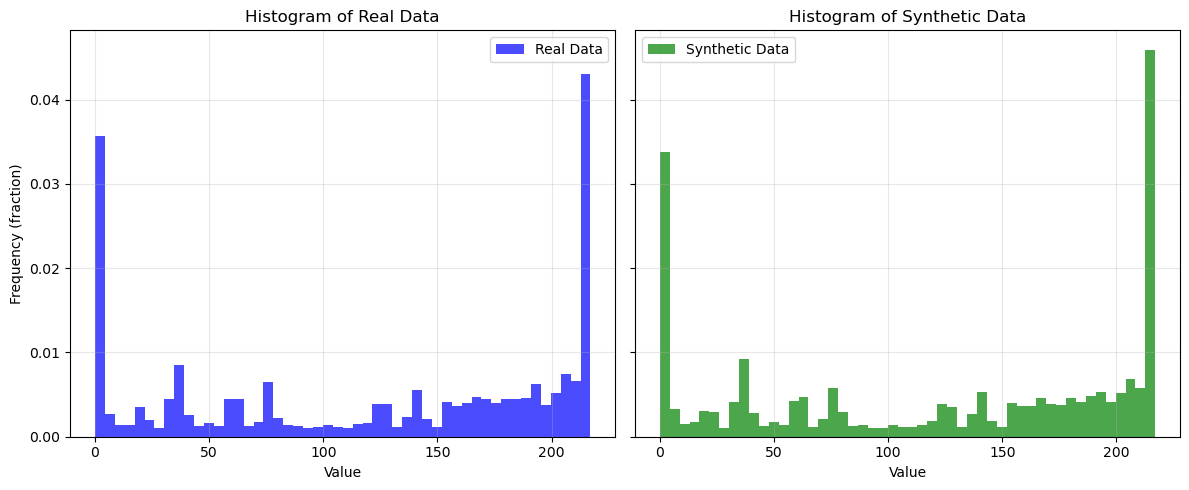

In [31]:
# state distribution

# load tm
from matplotlib import axis

with open("/cs/usr/roi.eliasian/LabFolder/Master/NPC-markov/data/transition_matrices/interactions-150-180-sym-diag+0.pickle", "rb") as f:
# with open("data/transition_matrices/interactions-150-180-symmetric-100ns.pickle", "rb") as f:
# with open(f"data/transition_matrices/interactions-150-180-symmetric-100ns-0init.pickle", "rb") as f:
    tm, states = pickle.load(f)
    
# Load anchor coordinates
with open(f"data/anchor_coordinates.pickle", "rb") as f:
    anchor_coordinates = pickle.load(f)

# Sort anchor coordinates by Z and reorder transition matrix
anchor_coordinates = dict(sorted(anchor_coordinates.items(), key=lambda x: x[1][2]))
new_states = ["nuc"] + list(anchor_coordinates.keys()) + ["cyt"]
tm = reorder_transition_matrix(tm, states, new_states)


# load real data
with open ('data/categorized/interactions-150-180-100ns.pickle', 'rb') as f:
    data = pickle.load(f)

# convert data to numbers by z axis
with open(f"data/anchor_coordinates.pickle", "rb") as f:
    anchor_coordinates = pickle.load(f)
anchor_coordinates = dict(sorted(anchor_coordinates.items(), key=lambda x: x[1][2]))
new_states = ["nuc"] + list(anchor_coordinates.keys()) + ["cyt"]
state_to_index = {state: i for i, state in enumerate(new_states)}
vectorized_lookup = np.vectorize(lambda x: state_to_index.get(x, 0))  # 0 is default if key not found
data = vectorized_lookup(data)

selected_indices = np.random.choice(data.shape[0], size=1000, replace=False)
data = data[selected_indices]

def count_values(series):
    return np.bincount(series, minlength=218)# This gives counts for values 0 to 217

norm_data = np.apply_along_axis(count_values, axis=1, arr=data)
norm_data = np.sum(norm_data, axis=0)
norm_data = norm_data / np.sum(norm_data)

# generate markov data
n_series = data.shape[0]
series_len = data.shape[1]
synthetic_data = np.zeros((n_series, series_len))
for i in range(n_series):
    synthetic_data[i] = sim_mm(tm, length=series_len - 1, init_dist=norm_data)
    
    
    
plot_side_by_side_histograms(data.flatten(), synthetic_data.flatten(), bins=50, labels=('Real Data', 'Synthetic Data'), titles=('Histogram of Real Data', 'Histogram of Synthetic Data'), figsize=(12, 5))

In [17]:

def multi_compare_transports():
    # load real data
    with open ('data/categorized/interactions-150-180-100ns.pickle', 'rb') as f:
        real_data = pickle.load(f)
        
    # convert data to numbers by z axis
    with open(f"data/anchor_coordinates.pickle", "rb") as f:
        anchor_coordinates = pickle.load(f)
    anchor_coordinates = dict(sorted(anchor_coordinates.items(), key=lambda x: x[1][2]))
    new_states = ["nuc"] + list(anchor_coordinates.keys()) + ["cyt"]
    state_to_index = {state: i for i, state in enumerate(new_states)}
    vectorized_lookup = np.vectorize(lambda x: state_to_index.get(x, 0))  # 0 is default if key not found
    real_data = vectorized_lookup(real_data)

    # calculate init dist
    def count_values(series):
        return np.bincount(series, minlength=218)# This gives counts for values 0 to 217
    norm_data = np.apply_along_axis(count_values, axis=1, arr=real_data)
    norm_data = np.sum(norm_data, axis=0)
    norm_data = norm_data / np.sum(norm_data)
    
    layer_names = ["Nuc", "Nup2", "Nup60", "Nup2", "Nup60", "Nup1", "Nup145", 
                "Nup49", "Nsp1", "Nup49", "Nsp1", "Nup57", "Nup145", 
                "Nup57", "Nup57", "Nup57", "Nsp1", "Nup49", "Nsp1", 
                "Nup49", "Nup100", "Nup159", "Nup100", "Nup159", 
                "Nsp1", "Nsp1", "Nup116", "Nup116", "Cyt"]
    n_layers = len(layer_names)
    md_transports = np.zeros((n_layers+2, n_layers+2))
    markov_transports = np.zeros((n_layers+2, n_layers+2))

    
    args_list = [(real_data, norm_data, bottom_state, top_state) for top_state in range(31) for bottom_state in range(top_state)]
    num_cpus = len(os.sched_getaffinity(0))
    print(f"Using {num_cpus} CPUs")
    with mp.Pool(processes=num_cpus) as pool:
        results = pool.map(compare_tranports_wrapper, args_list)
    print(results[0])
    for bottom_state, top_state, md_t, markov_t in results:
        md_transports[bottom_state, top_state], markov_transports[bottom_state, top_state] = md_t, markov_t
    return md_transports

def compare_tranports_wrapper(args):
    return (*compare_tranports(*args), args[2], args[3])

def compare_tranports(real_data, init_dist, bottom_state, top_state):
    if bottom_state == 0:
        bottom_states = [0]
    elif bottom_state == 30:
        bottom_states = [217]
    else:
        bottom_states = [bottom_state*8 + i for i in range(1, 9)]
    if top_state == 0:
        top_states = [0]
    elif top_state == 30:
        top_states = [217]
    else:
        top_states = [top_state*8 + i for i in range(1, 9)]
    
    # count real transports
    md_transports = 0
    for i in range(real_data.shape[0]):
        md_transports += calc_transports(real_data[i],
                                        bottom_states=bottom_states,
                                        top_states=top_states)
        
    # count synthetic transports
    markov_trasports = permiability_from_path(matrix_path="/cs/usr/roi.eliasian/LabFolder/Master/NPC-markov/data/transition_matrices/interactions-150-180-sym-diag+0.pickle",
                        n_sims=1, # 5 molecules = 1 uM, 250 molecules = 50 uM
                        sim_length=300, # 10000 steps = 1 ms, 1000 steps = 100 us
                        bottom_states=bottom_states,
                        top_states=top_states,
                        init_dist=init_dist) 
    return md_transports, markov_trasports
    
# 55 1075
    

In [ ]:
md_transports, markov_trasports = multi_compare_transports()

Using 16 CPUs


In [14]:
# get the rows of real transport where both 0 and 217 appear
def get_rows_with_both_0_and_217(data):
    rows = []
    for i in range(data.shape[0]):
        if 0 in data[i] and (217 in data[i] or 216 in data[i] or 215 in data[i] or 214 in data[i] or 213 in data[i]):
            rows.append(i)
    return rows
rows = get_rows_with_both_0_and_217(real_data)